# A/B Test Results: New Checkout Button
## Executive Summary
This report presents the results of an A/B test conducted to evaluate 
whether a new checkout button design increases conversion rate on our 
e-commerce platform.

**Test Period:** 2024  
**Total Users:** 10,000  
**Control Group:** 5,000 users (old button)  
**Treatment Group:** 5,000 users (new button)

In [1]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns
from scipy import stats
from statsmodels.stats.proportion import proportions_ztest

df = pd.read_csv('../data/raw/ab_test_data.csv')
control = df[df['group'] == 'control']['converted']
treatment = df[df['group'] == 'treatment']['converted']

control_rate = control.mean()
treatment_rate = treatment.mean()
uplift = (treatment_rate - control_rate) / control_rate * 100
counts = [treatment.sum(), control.sum()]
nobs = [len(treatment), len(control)]
z_stat, p_value = proportions_ztest(counts, nobs)
extra_purchases = (treatment_rate - control_rate) * 1_000_000

## Key Findings

| Metric | Control | Treatment |
|--------|---------|-----------|
| Users | 5,000 | 5,000 |
| Conversions | 479 | 567 |
| Conversion Rate | 9.58% | 11.34% |
| Relative Uplift | - | +18.37% |
| P-value | - | 0.0040 |

C:\Users\zubiya shaikh\AppData\Local\Temp\ipykernel_1548\1774449904.py:2: FutureWarning: 

Passing `palette` without assigning `hue` is deprecated and will be removed in v0.14.0. Assign the `x` variable to `hue` and set `legend=False` for the same effect.

  sns.barplot(data=df.groupby('group')['converted'].mean().reset_index(),


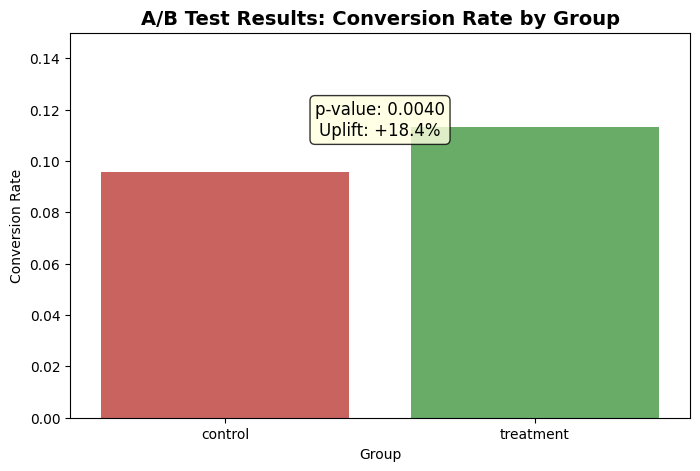

In [2]:
fig, ax = plt.subplots(figsize=(8, 5))
sns.barplot(data=df.groupby('group')['converted'].mean().reset_index(), 
            x='group', y='converted', 
            palette=['#d9534f', '#5cb85c'], ax=ax)
ax.set_title('A/B Test Results: Conversion Rate by Group', 
             fontsize=14, fontweight='bold')
ax.set_ylabel('Conversion Rate')
ax.set_xlabel('Group')
ax.set_ylim(0, 0.15)
ax.annotate(f'p-value: {p_value:.4f}\nUplift: +{uplift:.1f}%', 
            xy=(0.5, 0.11), fontsize=12, ha='center',
            bbox=dict(boxstyle='round', facecolor='lightyellow', alpha=0.8))
plt.savefig('../reports/figures/final_results.png', dpi=150, bbox_inches='tight')
plt.show()

## Recommendation: LAUNCH THE NEW BUTTON ✅

Based on the A/B test results, we recommend full rollout of the new 
checkout button for the following reasons:

**Statistical Evidence:**
- Conversion rate increased from 9.58% to 11.34%
- Result is statistically significant (p=0.0040 < 0.05)
- We are 99.6% confident this result is not due to random chance

**Business Impact:**
- 18.4% relative uplift in conversion rate
- 17,600 additional purchases per month at 1M visitors
- Both groups were balanced (5,000 users each) — experiment is valid

**Decision:** Reject the null hypothesis. The new button genuinely 
improves conversion rate. Recommend immediate full rollout.